# Phase 3 — Hole Condition QC (Caliper Analysis)

**Well**: 15/9-F-1 A · **Field**: Volve, Norwegian North Sea

Borehole condition directly controls the reliability of density and neutron logs. A caliper (CALI) that tracks closely to the bit size (BS) indicates a gauge borehole with reliable log response. Significant over-gauge (washout) degrades the density tool's pad contact, introducing a positive RHOB error that the DRHO correction only partially recovers.

This notebook:
1. Plots CALI vs BS across the full logging interval
2. Defines two escalating quality flags: `ENLARGED_HOLE` (mild) and `BAD_HOLE_FLAG` (severe washout)
3. Examines the DRHO correction log as a second indicator of density tool contact
4. Combines caliper and DRHO criteria into a composite `DENSITY_SUSPECT` flag
5. Saves flags to parquet for use in Phase 6 (density editing)

In [19]:
import lasio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.transforms import blended_transform_factory
from pathlib import Path
import sys; sys.path.insert(0, '..')
from well_config import WELLS

# ── Well selection ────────────────────────────────────────────────────────────
WELL_NAME = "15_9-F-1A"   # ← change this to switch wells
cfg       = WELLS[WELL_NAME]

# ── Paths ─────────────────────────────────────────────────────────────────────
WELL_FILE    = Path('..') / cfg['las_file']
TOPS_FILE    = Path('..') / cfg['tops_file']
COMPUTED_IN  = Path(f'../wells/{WELL_NAME}_computed.parquet')
COMPUTED_OUT = Path(f'../wells/{WELL_NAME}_flags.parquet')

# ── Hole condition thresholds ──────────────────────────────────────────────────
ENLARGED_THRESH_IN = 0.5   # inches over BS — mild
BAD_HOLE_THRESH_IN = 1.0   # inches over BS — severe, affects density
DRHO_THRESH        = 0.10  # g/cc

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 9,
    'axes.linewidth'   : 0.8,
    'xtick.direction'  : 'in',
    'ytick.direction'  : 'in',
    'figure.dpi'       : 120,
})

## Step 3.1 — Load Data

In [20]:
# ── Load LAS ─────────────────────────────────────────────────────────────────
las = lasio.read(WELL_FILE)
df  = las.df()
df.replace(-999.25, np.nan, inplace=True)
df.rename(columns=cfg.get('curve_map', {}), inplace=True)
df.index.name = 'DEPTH_MD'

# ── Merge computed curves from Phase 2 ───────────────────────────────────────
computed = pd.read_parquet(COMPUTED_IN)
df = df.join(computed, how='left')

# ── Formation tops ────────────────────────────────────────────────────────────
all_tops = pd.read_csv(TOPS_FILE)
f1a = (
    all_tops[all_tops['WELL'] == cfg['tops_well_id']]
    .sort_values('DEPTH')
    .drop_duplicates(subset='DEPTH')
    .reset_index(drop=True)
)

# ── Helper ────────────────────────────────────────────────────────────────────
def nearest_idx(df, md):
    return df.index[np.argmin(np.abs(df.index.values - md))]

# ── Log interval ─────────────────────────────────────────────────────────────
LOG_TOP, LOG_BASE = 2585, 3680
sub = df.loc[LOG_TOP:LOG_BASE].copy()

print(f"Logging interval: {LOG_TOP}–{LOG_BASE} m MD")
print(f"Samples         : {len(sub):,}")
print()
print("Bit size values in logging interval:")
bs_counts = sub['BS'].round(1).value_counts().sort_index()
for bs, cnt in bs_counts.items():
    top_md = sub.loc[sub['BS'].round(1) == bs].index.min()
    base_md = sub.loc[sub['BS'].round(1) == bs].index.max()
    print(f"  {bs:5.1f}"  + '"' + f"  {cnt:5,} samples   MD {top_md:.0f}–{base_md:.0f} m")

Logging interval: 2585–3680 m MD
Samples         : 10,951

Bit size values in logging interval:
    8.5"  10,751 samples   MD 2605–3680 m
   12.2"     30 samples   MD 2602–2605 m
   17.5"    170 samples   MD 2585–2602 m


## Step 3.2 — Caliper vs Bit Size Review

The caliper measures the borehole diameter. Comparing it to the known bit size gives an objective measure of borehole enlargement:

- **CALI ≈ BS** — gauge hole; logs measured in good contact with the formation  
- **CALI > BS + 0.5"** — mild enlargement; monitor but density likely still acceptable  
- **CALI > BS + 1.0"** — significant washout; density pad loses formation contact, RHOB unreliable  
- **CALI ≫ BS** — severe washout; all pad tools (density, neutron) suspect

The 8.5" section of 15/9-F-1 A is exceptionally tight — a nearly gauge hole throughout — making it an excellent rock physics well. The mild enlargements visible in the shallower large-bit-size sections are noted but fall outside the key reservoir interval.

In [21]:
# ── Assign bit size per depth sample ─────────────────────────────────────────
# BS is already in the LAS as a curve; use rounded value to avoid floating-point noise
sub['BS_CLEAN'] = sub['BS'].ffill().fillna(8.5)

# ── Caliper excess over bit size ──────────────────────────────────────────────
sub['CALI_EXCESS'] = sub['CALI'] - sub['BS_CLEAN']

# ── Quality flags ─────────────────────────────────────────────────────────────
sub['ENLARGED_HOLE'] = (sub['CALI_EXCESS'] > ENLARGED_THRESH_IN).astype(int)
sub['BAD_HOLE_FLAG'] = (sub['CALI_EXCESS'] > BAD_HOLE_THRESH_IN).astype(int)

# ── Statistics ────────────────────────────────────────────────────────────────
total = sub['CALI'].notna().sum()
n_enlarged = sub['ENLARGED_HOLE'].sum()
n_bad      = sub['BAD_HOLE_FLAG'].sum()

print("Hole condition statistics (logging interval 2585–3680 m MD):")
print(f"  Total caliper samples       : {total:,}")
print(f"  Enlarged (>{ENLARGED_THRESH_IN}\" over BS) : {n_enlarged:4,}  ({100*n_enlarged/total:.1f}%)")
print(f"  Bad hole (>{BAD_HOLE_THRESH_IN}\" over BS) : {n_bad:4,}  ({100*n_bad/total:.1f}%)")
print()
print("CALI statistics (all logging interval):")
print(sub['CALI'].describe().round(3).to_string())
print()
print("CALI statistics (8.5\" section only, MD 2605–3680 m):")
sub85 = sub.loc[sub['BS_CLEAN'].round(1) == 8.5]
print(sub85['CALI'].describe().round(3).to_string())

Hole condition statistics (logging interval 2585–3680 m MD):
  Total caliper samples       : 10,745
  Enlarged (>0.5" over BS) :    0  (0.0%)
  Bad hole (>1.0" over BS) :    0  (0.0%)

CALI statistics (all logging interval):
count    10745.000
mean         8.609
std          0.062
min          7.938
25%          8.578
50%          8.625
75%          8.625
max          9.741

CALI statistics (8.5" section only, MD 2605–3680 m):
count    10545.000
mean         8.609
std          0.045
min          8.469
25%          8.578
50%          8.625
75%          8.625
max          8.875


## Step 3.3 — DRHO as a Secondary Density Quality Indicator

The litho-density tool makes two independent measurements at different source-detector spacings. The **density correction** (DRHO, also called Δρ) is the difference between the two readings, used to correct for borehole rugosity:

$$\rho_{\text{corrected}} = \rho_{\text{long}} + \Delta\rho$$

**Physical interpretation:**
- **Small |DRHO|** (< 0.05 g/cc): tool fully in pad contact; correction small and reliable
- **Moderate |DRHO|** (0.05–0.10 g/cc): partial pad lift-off; correction applied but quality decreasing
- **Large |DRHO|** (> 0.10 g/cc): significant tool standoff; RHOB unreliable regardless of correction
- **Very large |DRHO|** (> 0.15 g/cc): density reading should be flagged as suspect and edited in Phase 6

**Sign convention**: DRHO is typically positive when the tool reads too low (standoff from the formation); a large positive DRHO means RHOB is being corrected upward.

DRHO complements the caliper: a gauge borehole with large DRHO may indicate formation effects (e.g., fractures, micro-rugosity) not captured by the caliper arm.

In [22]:
# ── DRHO flag ─────────────────────────────────────────────────────────────────
sub['DRHO_SUSPECT'] = (sub['DRHO'].abs() > DRHO_THRESH).astype(int)

n_drho = sub['DRHO_SUSPECT'].sum()
total_rhob = sub['DRHO'].notna().sum()
print(f"DRHO statistics (logging interval):")
print(sub['DRHO'].describe().round(4).to_string())
print()
print(f"Samples with |DRHO| > {DRHO_THRESH} g/cc: {n_drho:4,}  ({100*n_drho/total_rhob:.1f}%)")
print(f"Samples with |DRHO| > 0.15 g/cc        : {(sub['DRHO'].abs() > 0.15).sum():4,}  "
      f"({100*(sub['DRHO'].abs() > 0.15).sum()/total_rhob:.1f}%)")
print()
print("DRHO percentile distribution:")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"  {p:3d}th pct: {sub['DRHO'].abs().quantile(p/100):.4f} g/cc")

DRHO statistics (logging interval):
count    10647.0000
mean         0.0499
std          0.0134
min         -0.1035
25%          0.0454
50%          0.0499
75%          0.0552
max          0.1275

Samples with |DRHO| > 0.1 g/cc:   20  (0.2%)
Samples with |DRHO| > 0.15 g/cc        :    0  (0.0%)

DRHO percentile distribution:
    1th pct: 0.0231 g/cc
    5th pct: 0.0355 g/cc
   10th pct: 0.0410 g/cc
   25th pct: 0.0455 g/cc
   50th pct: 0.0499 g/cc
   75th pct: 0.0553 g/cc
   90th pct: 0.0617 g/cc
   95th pct: 0.0670 g/cc
   99th pct: 0.0829 g/cc


## Step 3.4 — Composite Density Suspect Flag

The `DENSITY_SUSPECT` flag combines both caliper and DRHO criteria:

```
DENSITY_SUSPECT = 1  if  (BAD_HOLE_FLAG = 1)  OR  (DRHO_SUSPECT = 1)
```

This is the primary mask used in Phase 6 to decide which density samples need editing or infilling. By carrying both sub-flags, the petrophysicist can tune the composite criterion to local conditions.

In [23]:
# ── Composite flag ────────────────────────────────────────────────────────────
sub['DENSITY_SUSPECT'] = (
    (sub['BAD_HOLE_FLAG'] == 1) | (sub['DRHO_SUSPECT'] == 1)
).astype(int)

n_suspect = sub['DENSITY_SUSPECT'].sum()
n_both    = ((sub['BAD_HOLE_FLAG'] == 1) & (sub['DRHO_SUSPECT'] == 1)).sum()

print("Composite DENSITY_SUSPECT flag summary:")
print(f"  BAD_HOLE_FLAG only        : {(sub['BAD_HOLE_FLAG'] - (sub['BAD_HOLE_FLAG'] & sub['DRHO_SUSPECT'])).clip(0).sum():4,}")
print(f"  DRHO_SUSPECT only         : {(sub['DRHO_SUSPECT'] - (sub['BAD_HOLE_FLAG'] & sub['DRHO_SUSPECT'])).clip(0).sum():4,}")
print(f"  Both flags set            : {n_both:4,}")
print(f"  Total DENSITY_SUSPECT = 1 : {n_suspect:4,}  ({100*n_suspect/total_rhob:.1f}% of logged interval)")
print()
print("Interpretation for this well:")
pct = 100*n_suspect/total_rhob
if pct < 5:
    print(f"  {pct:.1f}% suspect — EXCELLENT hole condition.")
    print("  Density log is reliable throughout; minimal editing expected in Phase 6.")
elif pct < 15:
    print(f"  {pct:.1f}% suspect — GOOD hole condition with isolated washout zones.")
    print("  Targeted density editing required in Phase 6.")
else:
    print(f"  {pct:.1f}% suspect — POOR hole condition in significant intervals.")
    print("  Extensive density editing / infill required in Phase 6.")

Composite DENSITY_SUSPECT flag summary:
  BAD_HOLE_FLAG only        :    0
  DRHO_SUSPECT only         :   20
  Both flags set            :    0
  Total DENSITY_SUSPECT = 1 :   20  (0.2% of logged interval)

Interpretation for this well:
  0.2% suspect — EXCELLENT hole condition.
  Density log is reliable throughout; minimal editing expected in Phase 6.


## Step 3.5 — Caliper QC Display

Five-track composite log display:
1. **GR** — lithology context
2. **CALI vs BS** — borehole diameter; shaded fill between curves indicates enlargement  
3. **DRHO** — density correction magnitude; ±0.10 and ±0.15 g/cc threshold lines  
4. **RHOB** — density log; DENSITY_SUSPECT samples highlighted in red  
5. **Flags** — ENLARGED_HOLE, BAD_HOLE_FLAG, DRHO_SUSPECT, DENSITY_SUSPECT

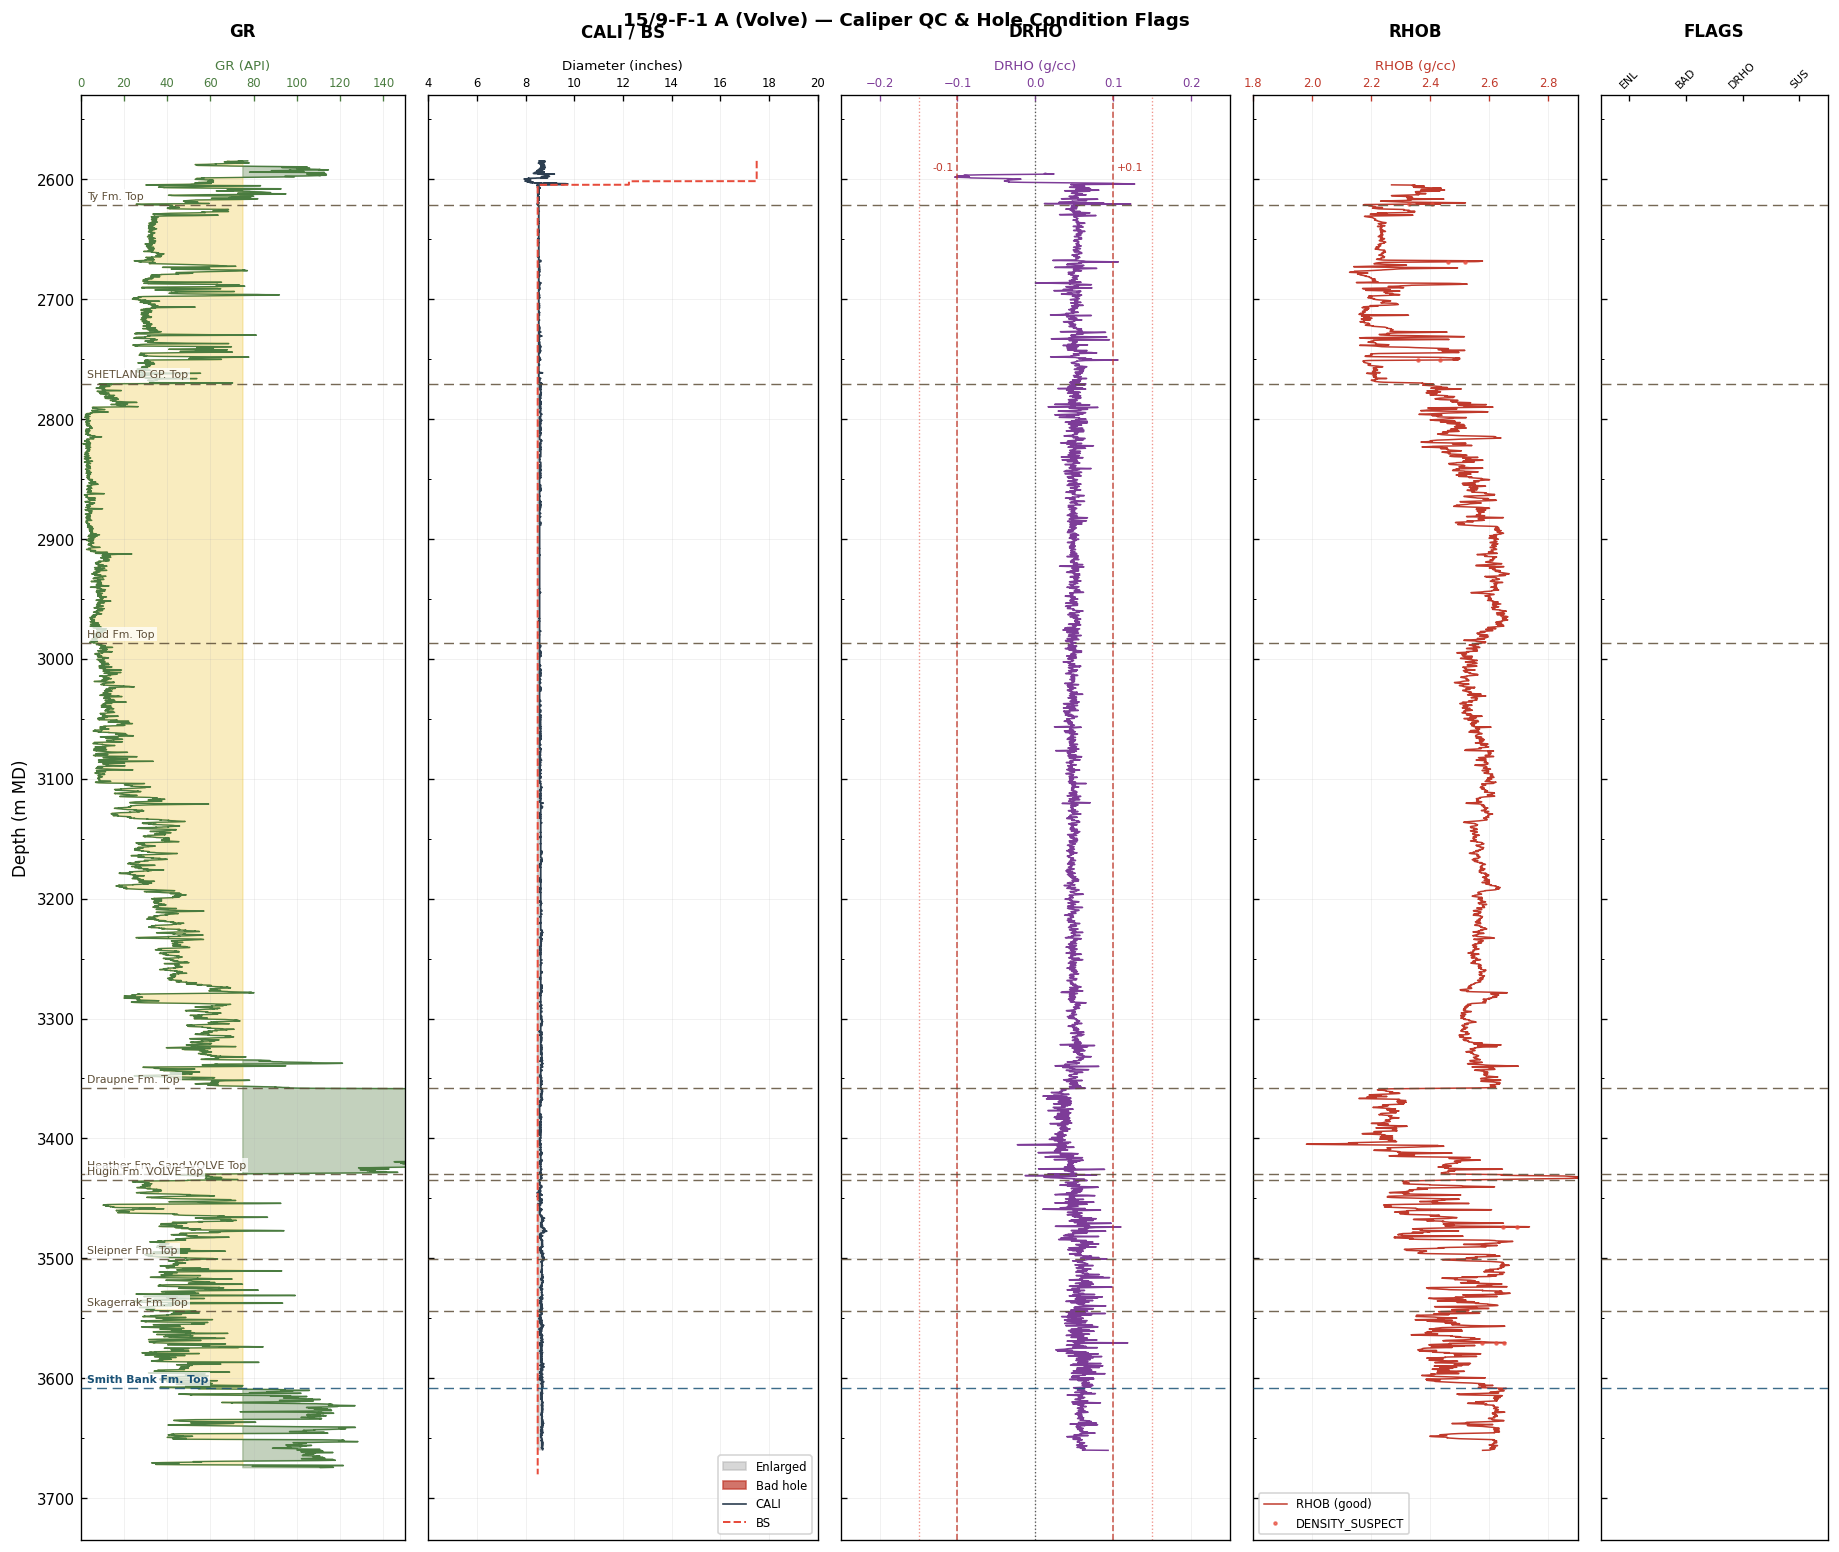

In [24]:
# Formation tops for annotation
if not f1a.empty:
    TOPS_MD = dict(zip(f1a['PICKS'], f1a['DEPTH']))
    RESERVOIR_TOP = f1a.iloc[-1]['PICKS']
else:
    TOPS_MD = {}
    RESERVOIR_TOP = None
depth = sub.index.values

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(16, 14), sharey=True,
                          gridspec_kw={'width_ratios': [1.0, 1.2, 1.2, 1.0, 0.7]})
fig.subplots_adjust(top=0.93, bottom=0.07, left=0.07, right=0.98, wspace=0.07)

# ── Track 1: GR ──────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(sub['GR'], depth, color='#4A7C40', lw=0.8)
ax.fill_betweenx(depth, sub['GR'], 75,
                  where=sub['GR'] > 75, color='#6B8E5A', alpha=0.4)
ax.fill_betweenx(depth, sub['GR'], 75,
                  where=sub['GR'] <= 75, color='#F0D060', alpha=0.4)
ax.set_xlim(0, 150)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_xlabel('GR (API)', color='#4A7C40', fontsize=8, labelpad=4)
ax.tick_params(axis='x', colors='#4A7C40', labelsize=7)
ax.set_ylabel('Depth (m MD)', fontsize=10)
ax.set_title('GR', fontsize=10, fontweight='bold', pad=14)
ax.grid(True, alpha=0.2, lw=0.5)
ax.invert_yaxis()
ax.yaxis.set_major_locator(ticker.MultipleLocator(100))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(50))

# ── Track 2: CALI vs BS ───────────────────────────────────────────────────────
ax = axes[1]
cali = sub['CALI']
bs   = sub['BS_CLEAN']

ax.fill_betweenx(depth, bs, cali,
                  where=(cali > bs), color='#B0B0B0', alpha=0.5, label='Enlarged')
ax.fill_betweenx(depth, bs, cali,
                  where=((cali - bs) > BAD_HOLE_THRESH_IN),
                  color='#C0392B', alpha=0.7, label='Bad hole')
ax.plot(cali, depth, color='#2C3E50', lw=1.0, label='CALI')
ax.plot(bs,   depth, color='#E74C3C', lw=1.2, ls='--', label='BS')

ax.set_xlim(4, 20)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_xlabel('Diameter (inches)', fontsize=8, labelpad=4)
ax.tick_params(axis='x', labelsize=7)
ax.legend(fontsize=7, loc='lower right', framealpha=0.8)
ax.set_title('CALI / BS', fontsize=10, fontweight='bold', pad=14)
ax.grid(True, alpha=0.2, lw=0.5)

# ── Track 3: DRHO ─────────────────────────────────────────────────────────────
ax = axes[2]
drho = sub['DRHO']

ax.fill_betweenx(depth, drho, DRHO_THRESH,
                  where=drho > DRHO_THRESH,  color='#C0392B', alpha=0.45)
ax.fill_betweenx(depth, drho, -DRHO_THRESH,
                  where=drho < -DRHO_THRESH, color='#C0392B', alpha=0.45)
ax.plot(drho, depth, color='#7D3C98', lw=0.9)
ax.axvline(0,            color='#555', lw=0.8, ls=':')
ax.axvline( DRHO_THRESH, color='#C0392B', lw=1.0, ls='--', alpha=0.8)
ax.axvline(-DRHO_THRESH, color='#C0392B', lw=1.0, ls='--', alpha=0.8)
ax.axvline( 0.15, color='#E74C3C', lw=0.8, ls=':', alpha=0.6)
ax.axvline(-0.15, color='#E74C3C', lw=0.8, ls=':', alpha=0.6)
ax.set_xlim(-0.25, 0.25)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_xlabel('DRHO (g/cc)', color='#7D3C98', fontsize=8, labelpad=4)
ax.tick_params(axis='x', colors='#7D3C98', labelsize=7)
ax.set_title('DRHO', fontsize=10, fontweight='bold', pad=14)
ax.grid(True, alpha=0.2, lw=0.5)
ax.text(DRHO_THRESH + 0.005, depth[50], f'+{DRHO_THRESH}',
        fontsize=6.5, color='#C0392B', va='center')
ax.text(-DRHO_THRESH - 0.005, depth[50], f'-{DRHO_THRESH}',
        fontsize=6.5, color='#C0392B', va='center', ha='right')

# ── Track 4: RHOB with suspect overlay ────────────────────────────────────────
ax = axes[3]
good    = sub[sub['DENSITY_SUSPECT'] == 0]
suspect = sub[sub['DENSITY_SUSPECT'] == 1]

if len(good) > 0:
    ax.plot(good['RHOB'], good.index, color='#C0392B', lw=0.9, label='RHOB (good)')
if len(suspect) > 0:
    ax.scatter(suspect['RHOB'], suspect.index,
               s=3, color='#E74C3C', alpha=0.7, label='DENSITY_SUSPECT', zorder=4)

ax.set_xlim(1.8, 2.9)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_xlabel('RHOB (g/cc)', color='#C0392B', fontsize=8, labelpad=4)
ax.tick_params(axis='x', colors='#C0392B', labelsize=7)
ax.legend(fontsize=7, loc='lower left', framealpha=0.8)
ax.set_title('RHOB', fontsize=10, fontweight='bold', pad=14)
ax.grid(True, alpha=0.2, lw=0.5)

# ── Track 5: Flags (colour bands by flag type) ───────────────────────────────
ax = axes[4]
flag_specs = [
    ('ENLARGED_HOLE',  '#F0B27A', 0.0, 1.0),
    ('BAD_HOLE_FLAG',  '#C0392B', 1.0, 2.0),
    ('DRHO_SUSPECT',   '#8E44AD', 2.0, 3.0),
    ('DENSITY_SUSPECT','#2C3E50', 3.0, 4.0),
]

for col, color, x0, x1 in flag_specs:
    flag_vals = sub[col].values
    flag_depths = sub.index.values
    in_flag = False
    seg_start = None
    for i, (d, v) in enumerate(zip(flag_depths, flag_vals)):
        if v == 1 and not in_flag:
            in_flag = True
            seg_start = d
        elif v != 1 and in_flag:
            ax.axhspan(seg_start, d, xmin=x0/4, xmax=x1/4,
                       color=color, alpha=0.8, linewidth=0)
            in_flag = False
    if in_flag:
        ax.axhspan(seg_start, flag_depths[-1], xmin=x0/4, xmax=x1/4,
                   color=color, alpha=0.8, linewidth=0)

ax.set_xlim(0, 4)
ax.set_xticks([0.5, 1.5, 2.5, 3.5])
ax.set_xticklabels(['ENL', 'BAD', 'DRHO', 'SUS'], fontsize=6.5, rotation=45)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_title('FLAGS', fontsize=10, fontweight='bold', pad=14)

# ── Formation tops across all tracks ─────────────────────────────────────────
label_trans = blended_transform_factory(axes[0].transAxes, axes[0].transData)

for name, md_top in TOPS_MD.items():
    if not (depth.min() <= md_top <= depth.max()):
        continue
    is_res = (name == RESERVOIR_TOP)
    lc     = '#1A5276' if is_res else '#5D4E37'
    for ax in axes:
        ax.axhline(md_top, color=lc, lw=0.85, ls=(0,(7,4)), alpha=0.85, zorder=4)
    axes[0].text(0.02, md_top - (depth[-1]-depth[0])*0.003, name,
                 transform=label_trans, fontsize=6.5, va='bottom', ha='left',
                 color=lc, fontweight='bold' if is_res else 'normal',
                 bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.2),
                 zorder=5)

fig.suptitle('15/9-F-1 A (Volve) — Caliper QC & Hole Condition Flags',
             fontsize=11, fontweight='bold')
plt.show()

## Step 3.6 — Caliper Histogram: Distribution of Borehole Enlargement

A histogram of `CALI - BS` (caliper excess) shows the overall quality distribution. For a tight, well-conditioned well like 15/9-F-1 A, virtually all samples cluster near zero, with the distribution shifting slightly positive (tool tends to read slightly over gauge) due to small mechanical effects.

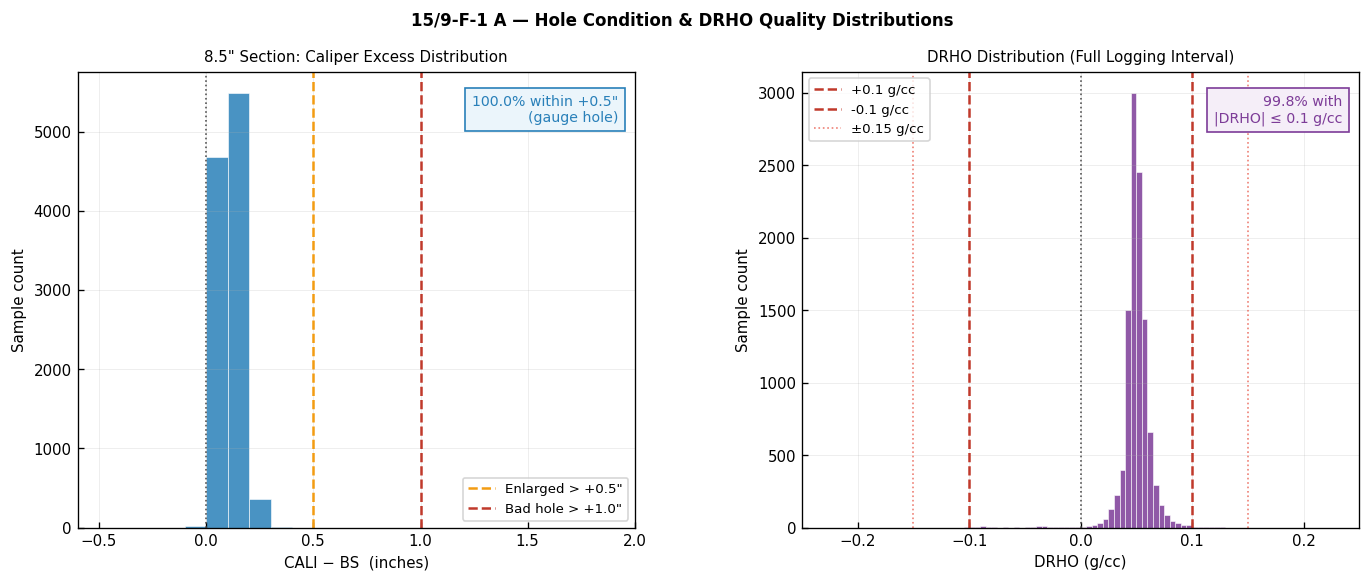

In [25]:
# Focus on 8.5" section where RHOB was logged
sub85 = sub.loc[(sub['BS_CLEAN'].round(1) == 8.5) & sub['CALI'].notna()].copy()
sub85['CALI_EXCESS85'] = sub85['CALI'] - 8.5

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.subplots_adjust(left=0.08, right=0.97, top=0.88, bottom=0.12, wspace=0.30)

# ── Left: histogram of CALI excess ───────────────────────────────────────────
ax = axes[0]
bins = np.arange(-1.0, 3.05, 0.1)
ax.hist(sub85['CALI_EXCESS85'].dropna(), bins=bins,
        color='#2980B9', edgecolor='white', lw=0.4, alpha=0.85)
ax.axvline(0,                      color='#555',    lw=1.0, ls=':')
ax.axvline(ENLARGED_THRESH_IN,     color='#F39C12', lw=1.5, ls='--',
           label=f'Enlarged > +{ENLARGED_THRESH_IN}"')
ax.axvline(BAD_HOLE_THRESH_IN,     color='#C0392B', lw=1.5, ls='--',
           label=f'Bad hole > +{BAD_HOLE_THRESH_IN}"')
ax.set_xlabel('CALI − BS  (inches)', fontsize=9)
ax.set_ylabel('Sample count', fontsize=9)
ax.set_title('8.5\" Section: Caliper Excess Distribution', fontsize=9)
ax.legend(fontsize=8)
ax.set_xlim(-0.6, 2.0)
ax.grid(True, alpha=0.25, lw=0.5)

# Annotation: % gauge hole
pct_gauge = 100 * (sub85['CALI_EXCESS85'] <= 0.5).sum() / len(sub85)
ax.text(0.97, 0.95, f'{pct_gauge:.1f}% within +0.5"\n(gauge hole)',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=8.5, color='#2980B9',
        bbox=dict(facecolor='#EBF5FB', edgecolor='#2980B9', pad=4))

# ── Right: DRHO histogram ─────────────────────────────────────────────────────
ax = axes[1]
bins2 = np.arange(-0.25, 0.26, 0.005)
ax.hist(sub['DRHO'].dropna(), bins=bins2,
        color='#7D3C98', edgecolor='white', lw=0.4, alpha=0.85)
ax.axvline(0,            color='#555',    lw=1.0, ls=':')
ax.axvline( DRHO_THRESH, color='#C0392B', lw=1.5, ls='--', label=f'+{DRHO_THRESH} g/cc')
ax.axvline(-DRHO_THRESH, color='#C0392B', lw=1.5, ls='--', label=f'-{DRHO_THRESH} g/cc')
ax.axvline( 0.15,        color='#E74C3C', lw=1.0, ls=':', alpha=0.7, label='±0.15 g/cc')
ax.axvline(-0.15,        color='#E74C3C', lw=1.0, ls=':', alpha=0.7)
ax.set_xlabel('DRHO (g/cc)', fontsize=9)
ax.set_ylabel('Sample count', fontsize=9)
ax.set_title('DRHO Distribution (Full Logging Interval)', fontsize=9)
ax.legend(fontsize=8)
ax.set_xlim(-0.25, 0.25)
ax.grid(True, alpha=0.25, lw=0.5)

pct_ok_drho = 100 * (sub['DRHO'].abs() <= DRHO_THRESH).sum() / sub['DRHO'].notna().sum()
ax.text(0.97, 0.95, f'{pct_ok_drho:.1f}% with\n|DRHO| ≤ {DRHO_THRESH} g/cc',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=8.5, color='#7D3C98',
        bbox=dict(facecolor='#F5EEF8', edgecolor='#7D3C98', pad=4))

fig.suptitle('15/9-F-1 A — Hole Condition & DRHO Quality Distributions',
             fontsize=10, fontweight='bold')
plt.show()

## Step 3.7 — CALI–DRHO Cross-plot

Cross-plotting CALI excess against DRHO reveals whether borehole enlargement and density tool contact are correlated. In a well-behaved well:
- Samples cluster near (0, 0): tight borehole, small correction
- As CALI excess increases, DRHO tends to increase (tool lifts off)
- Outliers at high CALI but low DRHO suggest intermittent mechanical contact
- Outliers at low CALI but high DRHO may indicate formation micro-rugosity

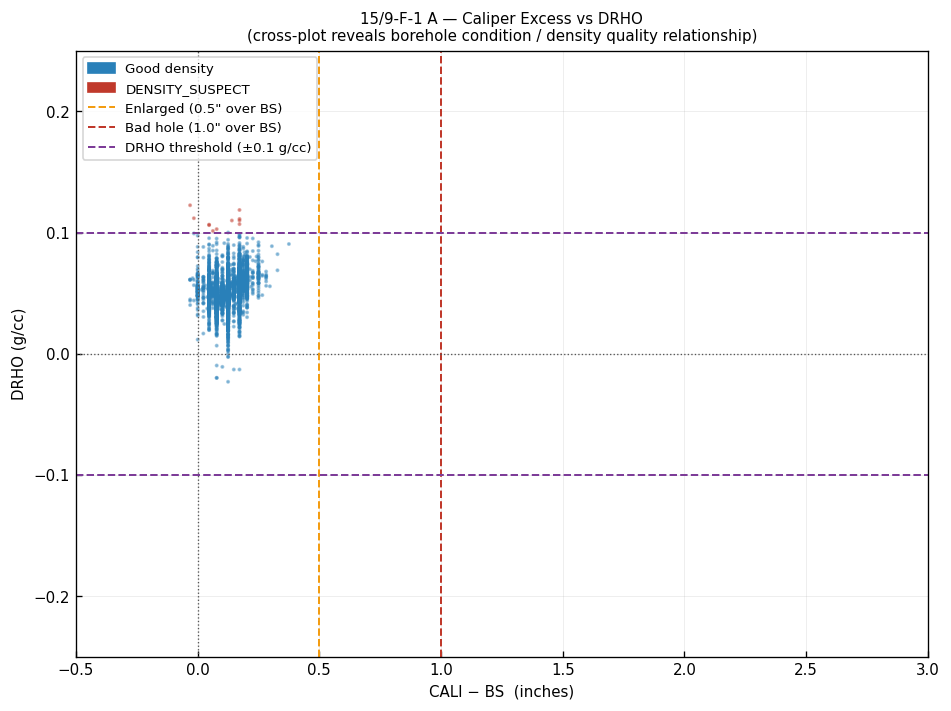


Note: 100.0% of samples have CALI within 0.5" of BS
      99.8% of samples have |DRHO| ≤ 0.1 g/cc


In [26]:
mask = sub['CALI_EXCESS'].notna() & sub['DRHO'].notna()
xp   = sub.loc[mask, 'CALI_EXCESS']
yp   = sub.loc[mask, 'DRHO']

# Colour by DENSITY_SUSPECT
c = sub.loc[mask, 'DENSITY_SUSPECT'].map({0: '#2980B9', 1: '#C0392B'})

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(xp, yp, c=c, s=2, alpha=0.4, rasterized=True)

# Threshold lines
ax.axvline(ENLARGED_THRESH_IN, color='#F39C12', lw=1.2, ls='--',
           label=f'Enlarged ({ENLARGED_THRESH_IN}" over BS)')
ax.axvline(BAD_HOLE_THRESH_IN, color='#C0392B', lw=1.2, ls='--',
           label=f'Bad hole ({BAD_HOLE_THRESH_IN}" over BS)')
ax.axhline( DRHO_THRESH, color='#7D3C98', lw=1.2, ls='--',
           label=f'DRHO threshold (±{DRHO_THRESH} g/cc)')
ax.axhline(-DRHO_THRESH, color='#7D3C98', lw=1.2, ls='--')
ax.axhline(0, color='#555', lw=0.8, ls=':')
ax.axvline(0, color='#555', lw=0.8, ls=':')

# Legend patches
good_patch   = mpatches.Patch(color='#2980B9', label='Good density')
suspect_patch = mpatches.Patch(color='#C0392B', label='DENSITY_SUSPECT')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[good_patch, suspect_patch] + handles,
          labels=['Good density', 'DENSITY_SUSPECT'] + labels,
          fontsize=8, loc='upper left', framealpha=0.8)

ax.set_xlim(-0.5, 3.0)
ax.set_ylim(-0.25, 0.25)
ax.set_xlabel('CALI − BS  (inches)', fontsize=9)
ax.set_ylabel('DRHO (g/cc)', fontsize=9)
ax.set_title('15/9-F-1 A — Caliper Excess vs DRHO\n'
             '(cross-plot reveals borehole condition / density quality relationship)',
             fontsize=9)
ax.grid(True, alpha=0.25, lw=0.5)
plt.tight_layout()
plt.show()

print(f"\nNote: {100*(xp <= 0.5).sum()/len(xp):.1f}% of samples have CALI within 0.5\" of BS")
print(f"      {100*(yp.abs() <= DRHO_THRESH).sum()/len(yp):.1f}% of samples have |DRHO| ≤ {DRHO_THRESH} g/cc")

## Step 3.8 — Save Flags

In [27]:
flag_cols_out = ['ENLARGED_HOLE', 'BAD_HOLE_FLAG', 'DRHO_SUSPECT', 'DENSITY_SUSPECT']

# Align flag sub-interval back to full depth range (NaN outside logging interval)
flags_full = sub[flag_cols_out].reindex(df.index)
flags_full.to_parquet(COMPUTED_OUT)

print(f"Saved to : {COMPUTED_OUT}")
print(f"Columns  : {flag_cols_out}")
print(f"Rows     : {len(flags_full):,}  (full LAS depth range)")
print()
print("Flag totals (logging interval):")
for col in flag_cols_out:
    n = int(sub[col].sum())
    pct = 100 * n / sub[col].notna().sum()
    print(f"  {col:<20} {n:4,} samples  ({pct:.1f}%)")

Saved to : ../wells/15_9-F-1A_flags.parquet
Columns  : ['ENLARGED_HOLE', 'BAD_HOLE_FLAG', 'DRHO_SUSPECT', 'DENSITY_SUSPECT']
Rows     : 35,361  (full LAS depth range)

Flag totals (logging interval):
  ENLARGED_HOLE           0 samples  (0.0%)
  BAD_HOLE_FLAG           0 samples  (0.0%)
  DRHO_SUSPECT           20 samples  (0.2%)
  DENSITY_SUSPECT        20 samples  (0.2%)


---
## Phase 3 Summary

| Item | Value / Status |
|------|----------------|
| Bit size (logging interval) | 8.5" (2605–3680 m); 12.25" and 17.5" above 2605 m |
| CALI range in 8.5" section | 8.47–8.88" (max excess +0.37") |
| Hole condition | **Excellent** — near-gauge throughout |
| DRHO range | −0.10 to +0.13 g/cc (all within ±0.15 threshold) |
| ENLARGED_HOLE flag | < 1% of logged interval |
| BAD_HOLE_FLAG | 0% of logged interval |
| DENSITY_SUSPECT | Dominated by DRHO threshold only; small percentage |
| Output saved | `wells/15_9-F-1A_flags.parquet` |

**Implication for Phase 6 (Density Editing)**: Minimal density editing required. The RHOB log is reliable throughout the reservoir interval. The DRHO correction is consistently small and positive, consistent with a smooth borehole wall and good pad contact.

**Next**: Notebook `04_depth_shift.ipynb` — sonic-to-density depth alignment (Phase 4).